<a href="https://colab.research.google.com/github/alisarupenyan/Intro_to_ML_FS26/blob/main/sigmoid_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# When does the sigmoid become a step function?

The steepness of the sigmoid is controlled by θ₁:

$$P(y=1 | x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x)}}$$

As |θ₁| → ∞, the sigmoid approaches a **step function**: the model assigns probability 0 or 1 everywhere, with no uncertainty except exactly at the boundary.

The step arises whenever the **training data is linearly separable** — there is a clean gap between the two classes in x. Two parameters control whether this happens:

- **sep**: larger separation → bigger gap between classes → separability more likely
- **σ**: smaller spread → points cluster tightly → gap preserved → separability more likely

Both act through the same mechanism. We will show each in turn, then explain why separability causes the training procedure to break down.

## Setup: data generation

Each dataset contains two classes, drawn from two Gaussians with equal variance:

$$x \mid y=0 \sim \mathrm{N}\left(-\frac{\text{sep}}{2},\ \sigma^2\right), \qquad x \mid y=1 \sim \mathrm{N}\left(+\frac{\text{sep}}{2},\ \sigma^2\right)$$

- **sep**: distance between the two class means
- **σ**: standard deviation of each class cluster

Their ratio is the signal-to-noise ratio: $\text{SNR} = \text{sep}/\sigma$

The population overlap between the two Gaussians is:

$$\text{overlap} = \operatorname{erfc}\left(\frac{\text{sep}}{2\sigma\sqrt{2}}\right) \times 100\%$$

**Important distinction**: the population overlap tells us about the underlying distributions.
What actually determines θ₁ is whether the **training points themselves** end up with a gap between them — which depends on both sep, σ, and the specific draw.
Sep and σ are the two knobs that make separability of the training set more or less likely.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.special import erfc
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def generate_data(n_per_class=10, class_sep=1.0, x_spread=1.0, seed=0):
    rng = np.random.RandomState(seed)
    X0  = rng.normal(loc=-class_sep/2, scale=x_spread, size=n_per_class)
    X1  = rng.normal(loc=+class_sep/2, scale=x_spread, size=n_per_class)
    X   = np.concatenate([X0, X1]).reshape(-1, 1)
    y   = np.array([0]*n_per_class + [1]*n_per_class)
    return X, y

def fit_logistic(X, y, C=1e4):
    clf = LogisticRegression(C=C, solver='lbfgs', max_iter=10000)
    clf.fit(X, y)
    return clf.intercept_[0], clf.coef_[0, 0]

def sigmoid(x, t0, t1):
    return 1 / (1 + np.exp(-np.clip(t0 + t1*x, -100, 100)))

def overlap_pct(sep, spread):
    return 100 * erfc(sep / (2 * spread * np.sqrt(2)))

def is_separable(X, y):
    return X[y==0].max() < X[y==1].min() or X[y==1].max() < X[y==0].min()

def scatter_data(ax, X, y, seed):
    rng = np.random.RandomState(seed)
    j0  = rng.uniform(-0.04, 0.04, (y==0).sum())
    j1  = rng.uniform(-0.04, 0.04, (y==1).sum())
    ax.scatter(X[y==0], j0,     color='royalblue', s=50, alpha=0.9, zorder=3, label='class 0')
    ax.scatter(X[y==1], 1 + j1, color='tomato',    s=50, alpha=0.9, zorder=3, label='class 1')

def annotate_panel(ax, t1, sep_flag):
    color = 'darkred'
    ax.annotate(f'θ₁={t1:.1f}', xy=(0.97, 0.52), xycoords='axes fraction',
                ha='right', fontsize=10, color=color, fontweight='bold')
    if sep_flag:
        ax.annotate('separable', xy=(0.97, 0.08), xycoords='axes fraction',
                    ha='right', fontsize=8, color='darkorange', fontstyle='italic')

x_plot = np.linspace(-14, 14, 600)
SEED   = 7
N      = 10   # points per class — fixed throughout


## Effect 1 — Varying separation (fixed spread)

We fix σ = 0.8 and increase sep from 0 to 5. As sep grows, the class means move apart.
At some point the training points stop intermingling and a gap appears — the data becomes
linearly separable and θ₁ jumps.

Separable panels are marked *separable* in orange.

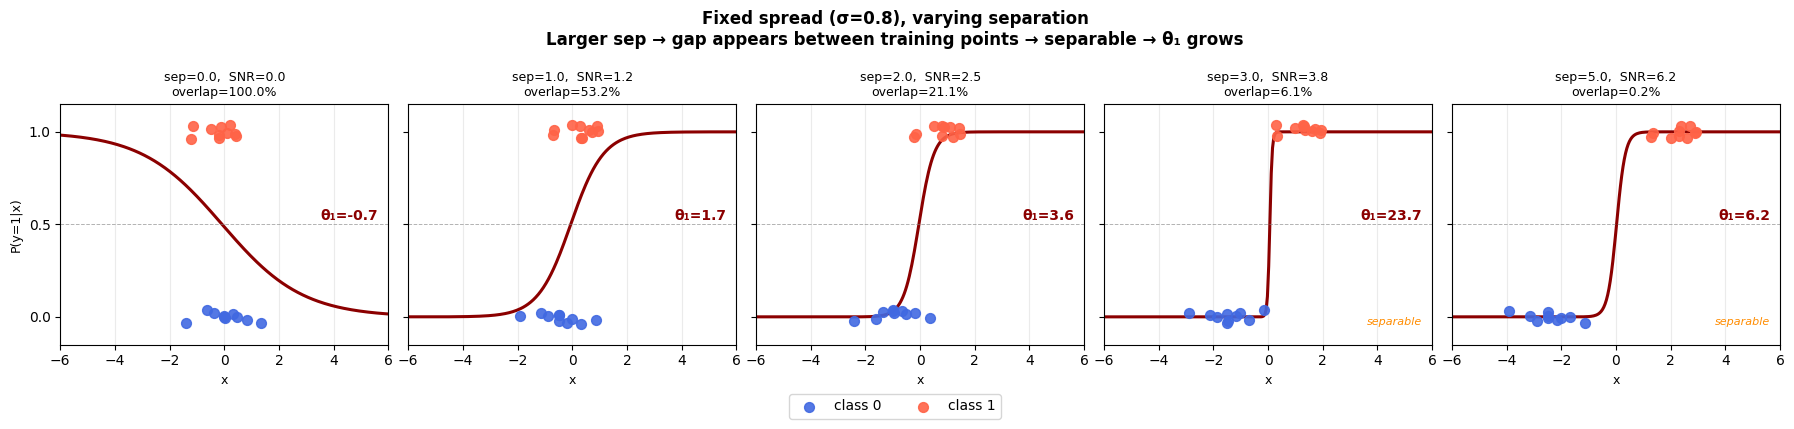

In [6]:
SPREAD_FIXED = 0.8
seps = [0.0, 1.0, 2.0, 3.0, 5.0]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle(f'Fixed spread (σ={SPREAD_FIXED}), varying separation\n'
              'Larger sep → gap appears between training points → separable → θ₁ grows',
             fontsize=12, fontweight='bold')

for ax, sep in zip(axes, seps):
    X, y   = generate_data(N, sep, SPREAD_FIXED, seed=SEED)
    t0, t1 = fit_logistic(X, y)
    ov     = overlap_pct(sep, SPREAD_FIXED)
    sep_flag = is_separable(X, y)

    ax.plot(x_plot, sigmoid(x_plot, t0, t1), color='darkred', linewidth=2.2, zorder=2)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    scatter_data(ax, X, y, seed=SEED + int(sep*10))
    annotate_panel(ax, t1, sep_flag)

    ax.set_title(f'sep={sep},  SNR={sep/SPREAD_FIXED:.1f}\noverlap={ov:.1f}%', fontsize=9)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-0.15, 1.15)
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel('x', fontsize=9)
    ax.grid(True, axis='x', alpha=0.25)

axes[0].set_ylabel('P(y=1|x)', fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig('effect1_separation.png', dpi=130, bbox_inches='tight')
plt.show()

## Effect 2 — Varying spread (fixed separation)

We fix sep = 3.0 and decrease σ from 3.5 to 0.3. As σ shrinks, the points cluster more
tightly around their means. Even with the same separation, a gap appears between the classes
and the data becomes separable.

This is the more counterintuitive case: the classes are not moving apart — the points are
simply becoming less scattered, which is enough to produce separability and drive θ₁ up.

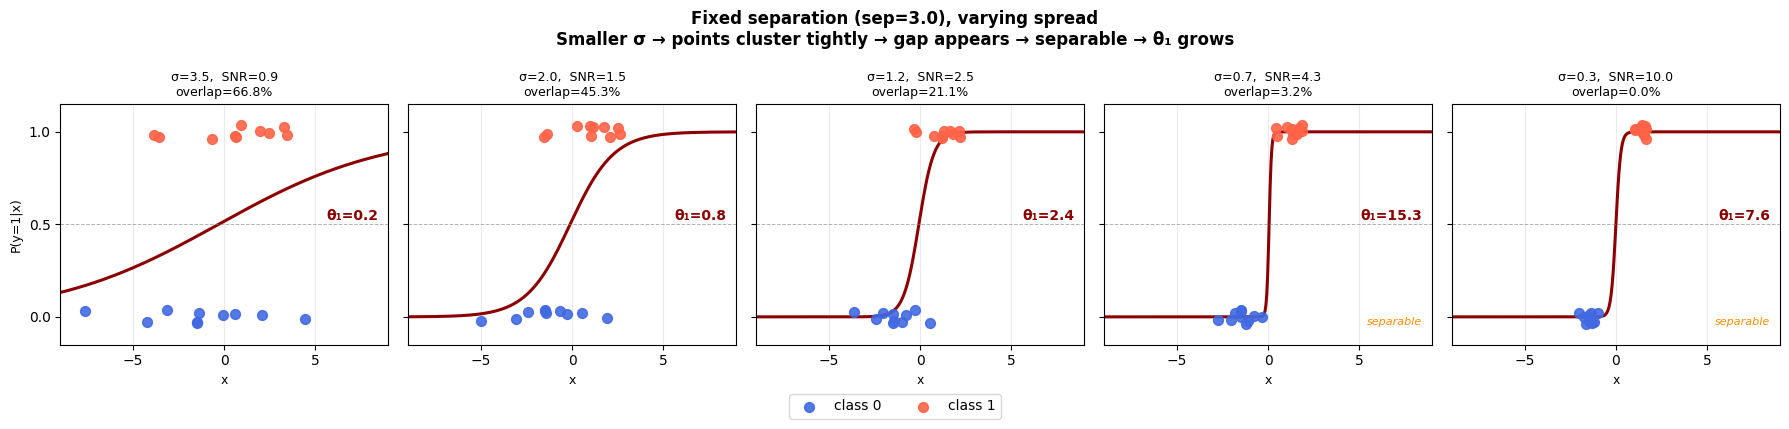

In [7]:
SEP_FIXED = 3.0
spreads   = [3.5, 2.0, 1.2, 0.7, 0.3]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle(f'Fixed separation (sep={SEP_FIXED}), varying spread\n'
              'Smaller σ → points cluster tightly → gap appears → separable → θ₁ grows',
             fontsize=12, fontweight='bold')

for ax, spread in zip(axes, spreads):
    X, y   = generate_data(N, SEP_FIXED, spread, seed=SEED)
    t0, t1 = fit_logistic(X, y)
    ov     = overlap_pct(SEP_FIXED, spread)
    sep_flag = is_separable(X, y)

    ax.plot(x_plot, sigmoid(x_plot, t0, t1), color='darkred', linewidth=2.2, zorder=2)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    scatter_data(ax, X, y, seed=SEED + int(spread*10))
    annotate_panel(ax, t1, sep_flag)

    ax.set_title(f'σ={spread},  SNR={SEP_FIXED/spread:.1f}\noverlap={ov:.1f}%', fontsize=9)
    ax.set_xlim(-9, 9)
    ax.set_ylim(-0.15, 1.15)
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel('x', fontsize=9)
    ax.grid(True, axis='x', alpha=0.25)

axes[0].set_ylabel('P(y=1|x)', fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig('effect2_spread.png', dpi=130, bbox_inches='tight')
plt.show()

## Why is linear separability a problem for logistic regression?

When the training data is linearly separable, the cross-entropy loss has **no finite minimum**:

$$\mathrm{L}(\theta) = -\sum_{i} \Bigl[ y_i \log \sigma(\theta_0 + \theta_1 x_i)
                                        + (1-y_i) \log(1 - \sigma(\theta_0 + \theta_1 x_i)) \Bigr]$$

For any separable dataset, making θ₁ larger always assigns higher confidence to the correct
class, which always reduces the loss — but only asymptotically reaches zero. There is no
finite θ₁ that minimises it. Gradient descent increments θ₁ indefinitely and **never converges**.

This is a property of the **loss function and the training data alone**. The optimizer sees
only the training points in front of it. If those points are separable, the MLE does not exist.

Consequences:

- **No convergence** — weights grow without bound, training never stabilises
- **Overconfident predictions** — probability ≈ 0 or 1 everywhere, including in regions with no training data
- **Numerical instability** — log(0) appears in the loss


### The fix: L2 regularization

Adding an L2 penalty modifies the loss:

$$\mathrm{L}_{\text{reg}}(\theta) = \mathrm{L}(\theta) + \frac{1}{2C}\|\theta\|^2$$

The penalty grows with |θ₁|, creating a finite minimum even for separable data.
Smaller C = stronger regularization = θ₁ pulled back more aggressively from infinity.

A step-like sigmoid is not automatically wrong. If the classes are truly separated and you only need a decision boundary, a threshold rule or hard-margin SVM is simpler and more principled. If you need probabilities, Naive Bayes or regularized logistic regression work fine. The real problem is a separable training set when the classes actually overlap - in that case the model is overconfident in exactly the region where it should be uncertain, and no regularization fully compensates for training data that does not sample the overlap region.

## Demonstration: regularization controls the steepness

In sklearn, regularization strength is controlled by C = 1/λ, where λ is the standard L2 penalty weight. Small C = large λ = strong regularization. In the plots below, we label by λ to match the standard convention.

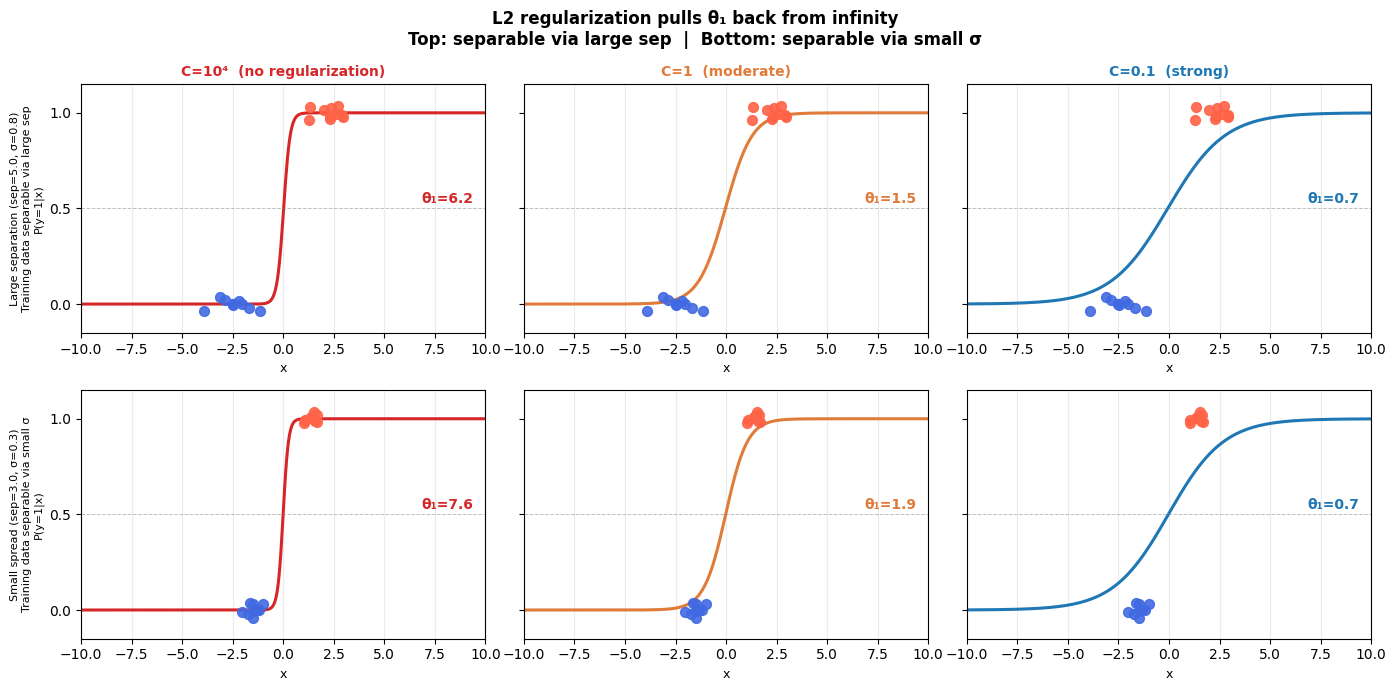

Both routes to separability are rescued by the same fix: L2 regularization.


In [8]:
C_values = [1e4,                    1.0,              0.1          ]
C_labels = ['λ≈0  (no reg)',        'λ=1  (moderate)', 'λ=10  (strong)']
colors_C = ['#d62728', '#e07b39', '#1f77b4']

# one case driven by large sep, one by small sigma — both produce separable training data
cases = [
    (0.8, 5.0, 'Large separation (sep=5.0, σ=0.8)\nTraining data separable via large sep'),
    (0.3, 3.0, 'Small spread (sep=3.0, σ=0.3)\nTraining data separable via small σ'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
fig.suptitle('L2 regularization pulls θ₁ back from infinity\n'
             'Top: separable via large sep  |  Bottom: separable via small σ',
             fontsize=12, fontweight='bold')

for r, (spread, sep, row_label) in enumerate(cases):
    X, y = generate_data(N, sep, spread, seed=SEED)
    for c, (C, cl, col) in enumerate(zip(C_values, C_labels, colors_C)):
        ax     = axes[r, c]
        t0, t1 = fit_logistic(X, y, C=C)

        ax.plot(x_plot, sigmoid(x_plot, t0, t1), color=col, linewidth=2.2, zorder=2)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
        scatter_data(ax, X, y, seed=SEED + r)

        ax.annotate(f'θ₁={t1:.1f}', xy=(0.97, 0.52), xycoords='axes fraction',
                    ha='right', fontsize=10, color=col, fontweight='bold')
        ax.set_xlim(-10, 10)
        ax.set_ylim(-0.15, 1.15)
        ax.set_yticks([0, 0.5, 1])
        ax.grid(True, axis='x', alpha=0.25)
        ax.set_xlabel('x', fontsize=9)

        if r == 0:
            ax.set_title(cl, fontsize=10, color=col, fontweight='bold')
        if c == 0:
            ax.set_ylabel(row_label + '\nP(y=1|x)', fontsize=8)

plt.tight_layout()
plt.savefig('regularization_effect.png', dpi=130, bbox_inches='tight')
plt.show()
print("Both routes to separability are rescued by the same fix: L2 regularization.")